In [4]:
# ==============================================================================
# ЯЧЕЙКА 1: Динамический анализ шума на ЦЕЛЫХ снимках (Временной ряд)
# ==============================================================================
import os
import numpy as np
import tifffile as tiff
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

print("🔍 Запуск послойного анализа шума (Time-Series Analysis)...")

# Пути к папкам (убедитесь, что они правильные)
NOISY_DIR = "filestore/filestorage/V_beton30_angle05"
CLEAN_DIR = "filestore/filestorage/V_beton30_angle005"

# 1. Получаем отсортированные списки файлов (важно для сохранения порядка Z-оси!)
noisy_files = sorted([f for f in os.listdir(NOISY_DIR) if f.lower().endswith(('.tif', '.tiff'))])
clean_files = sorted([f for f in os.listdir(CLEAN_DIR) if f.lower().endswith(('.tif', '.tiff'))])
# Оставляем только валидную зону, отбрасываем воздух и искажения
noisy_files = noisy_files[400:2430]
clean_files = clean_files[400:2430]
common_files = sorted(list(set(noisy_files) & set(clean_files)))

print(f"📁 Найдено {len(common_files)} общих срезов.")

# Чтобы не ждать вечность, возьмем каждый 10-й срез (шаг=10) для анализа тренда.
# Если хотите проанализировать прям ВСЕ, поставьте step = 1
step = 10 
selected_files = common_files[::step]

slice_indices = []
sigma_values = []
mean_values = []

# Для визуализации одного целого среза сохраним его
example_whole_noise = None 

# 2. Послойный расчет
for idx, filename in enumerate(tqdm(selected_files, desc="Анализ срезов")):
    n_path = os.path.join(NOISY_DIR, filename)
    c_path = os.path.join(CLEAN_DIR, filename)
    
    # Читаем целые снимки (3067 x 3067)
    n_img = tiff.imread(n_path).astype(np.float32)
    c_img = tiff.imread(c_path).astype(np.float32)
    
    # Вычисляем матрицу шума для ЦЕЛОГО снимка
    noise_img = n_img - c_img
    
    # Считаем параметры
    current_sigma = np.std(noise_img)
    current_mean = np.mean(noise_img)
    
    # Записываем в историю (временной ряд)
    # Умножаем idx на step, чтобы сохранить реальный номер среза по Z-оси
    slice_indices.append(idx * step) 
    sigma_values.append(current_sigma)
    mean_values.append(current_mean)
    
    # Сохраним срез из середины для гистограммы
    if idx == len(selected_files) // 2:
        example_whole_noise = noise_img

print("✅ Анализ завершен!")

🔍 Запуск послойного анализа шума (Time-Series Analysis)...
📁 Найдено 2030 общих срезов.


Анализ срезов: 100%|██████████| 203/203 [01:29<00:00,  2.26it/s]

✅ Анализ завершен!


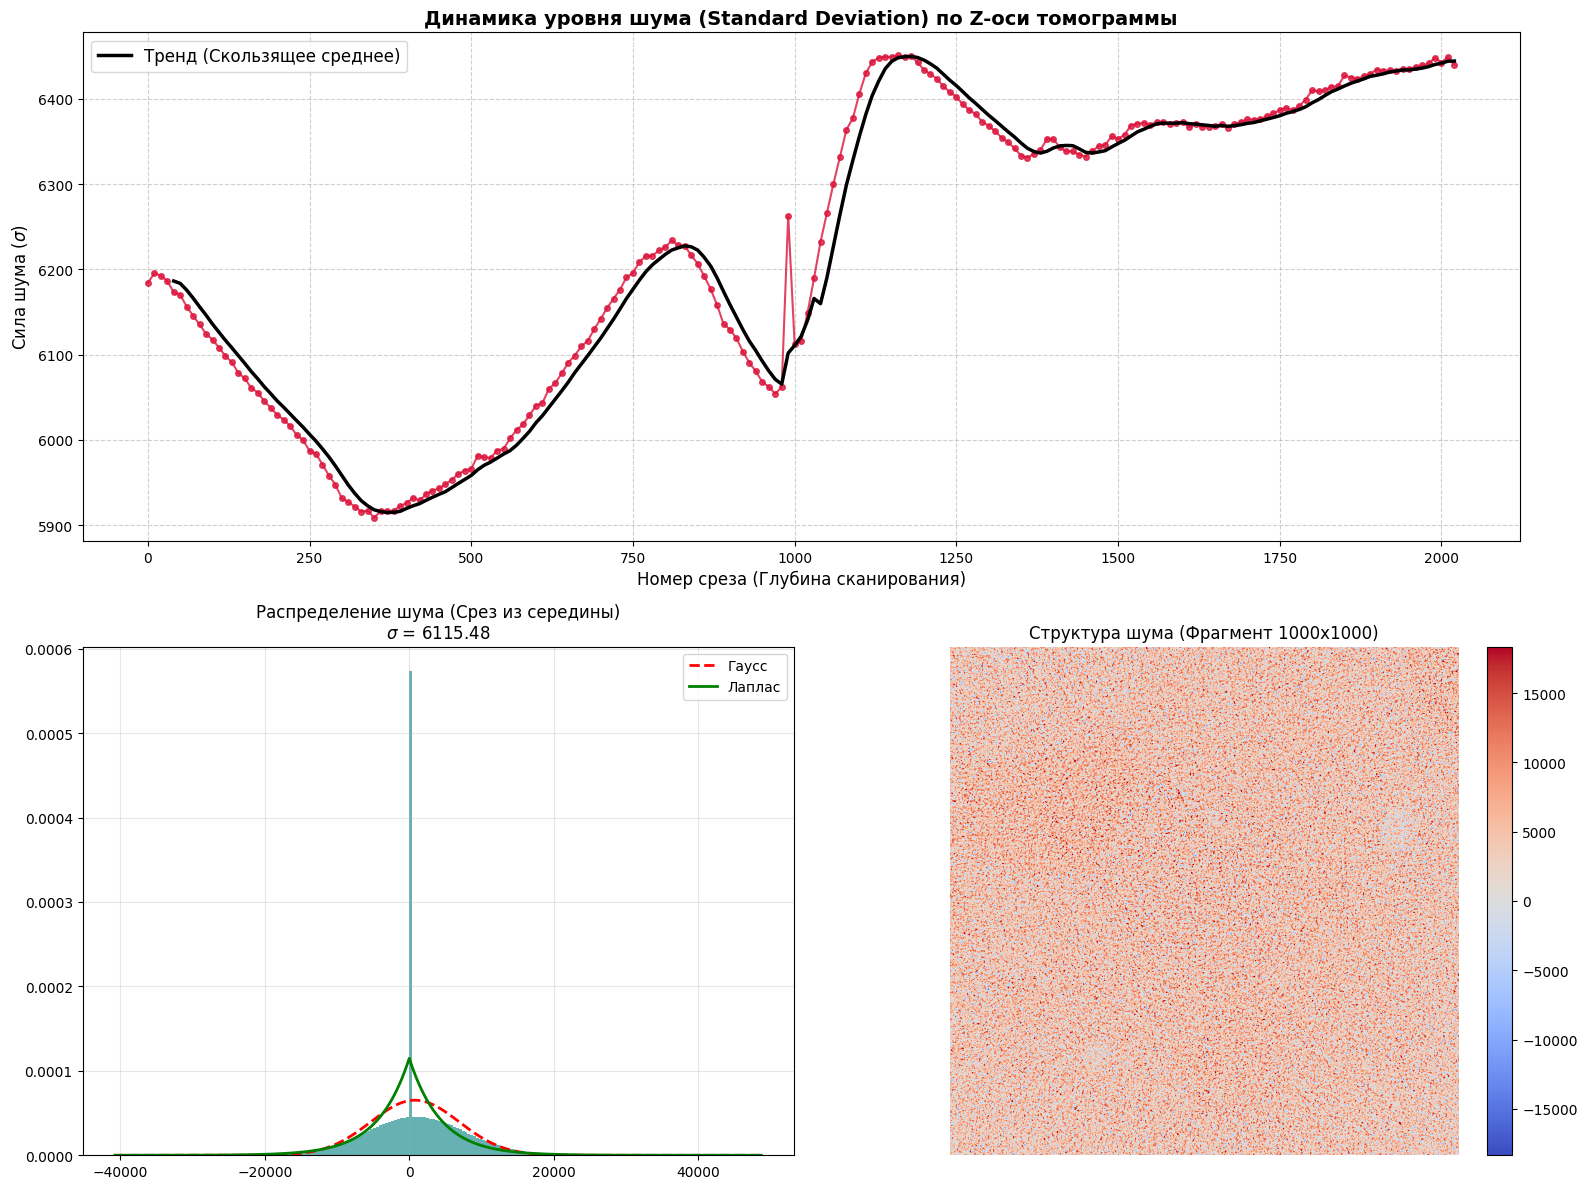

📊 ВЫВОДЫ ПО ДИНАМИКЕ ШУМА:
 • Минимальный шум ($\sigma$): 5908.53 (на срезе 350)
 • Максимальный шум ($\sigma$): 6450.84 (на срезе 1160)
 • Размах колебаний: 542.31


In [5]:
# ==============================================================================
# ЯЧЕЙКА 2: Визуализация динамики шума (Тренд) и Распределения
# ==============================================================================
import scipy.stats as stats

fig = plt.figure(figsize=(16, 12))

# --- ГРАФИК 1: Динамика шума (Временной ряд) ---
ax1 = plt.subplot(2, 1, 1)
ax1.plot(slice_indices, sigma_values, marker='o', linestyle='-', color='crimson', markersize=4, alpha=0.8)
ax1.set_title("Динамика уровня шума (Standard Deviation) по Z-оси томограммы", fontsize=14, fontweight='bold')
ax1.set_xlabel("Номер среза (Глубина сканирования)", fontsize=12)
ax1.set_ylabel("Сила шума ($\sigma$)", fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.6)

# Добавим линию тренда (скользящее среднее), чтобы увидеть глобальные изменения плотности
window = 5
if len(sigma_values) > window:
    trend = np.convolve(sigma_values, np.ones(window)/window, mode='valid')
    ax1.plot(slice_indices[window-1:], trend, color='black', linewidth=2.5, label='Тренд (Скользящее среднее)')
    ax1.legend(fontsize=12)

# --- ГРАФИК 2: Гистограмма шума ЦЕЛОГО снимка ---
ax2 = plt.subplot(2, 2, 3)

# Берем все пиксели из сохраненного целого снимка (~9.4 млн пикселей)
flat_noise = example_whole_noise.flatten()

# Строим гистограмму
ax2.hist(flat_noise, bins=200, density=True, alpha=0.6, color='teal')

# Фитим Гаусса и Лапласа для этого конкретного снимка
g_loc, g_scale = stats.norm.fit(flat_noise)
l_loc, l_scale = stats.laplace.fit(flat_noise)

xmin, xmax = ax2.get_xlim()
x = np.linspace(xmin, xmax, 1000)
ax2.plot(x, stats.norm.pdf(x, g_loc, g_scale), 'r--', lw=2, label='Гаусс')
ax2.plot(x, stats.laplace.pdf(x, l_loc, l_scale), 'g-', lw=2, label='Лаплас')

ax2.set_title(f"Распределение шума (Срез из середины)\n$\sigma$ = {np.std(flat_noise):.2f}", fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)

# --- ГРАФИК 3: Визуализация изолированного шума ---
ax3 = plt.subplot(2, 2, 4)
# Покажем кусочек шума 1000x1000 из центра, чтобы было видно структуру
center_y, center_x = example_whole_noise.shape[0]//2, example_whole_noise.shape[1]//2
noise_crop = example_whole_noise[center_y-500:center_y+500, center_x-500:center_x+500]

im = ax3.imshow(noise_crop, cmap='coolwarm', vmin=-g_scale*3, vmax=g_scale*3)
ax3.set_title("Структура шума (Фрагмент 1000x1000)", fontsize=12)
ax3.axis('off')
plt.colorbar(im, ax=ax3, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# Вывод аналитики
print("📊 ВЫВОДЫ ПО ДИНАМИКЕ ШУМА:")
print(f" • Минимальный шум ($\sigma$): {np.min(sigma_values):.2f} (на срезе {slice_indices[np.argmin(sigma_values)]})")
print(f" • Максимальный шум ($\sigma$): {np.max(sigma_values):.2f} (на срезе {slice_indices[np.argmax(sigma_values)]})")
print(f" • Размах колебаний: {np.max(sigma_values) - np.min(sigma_values):.2f}")